# TIFUUN Instrument Walkthrough

This notebook demonstrates how to use the AtLAST Sensitivity Calculator with the TIFUUN (Terahertz IFU with Universal Nanotechnology) instrument. TIFUUN is a wideband integral field unit designed for the ASTE telescope.

## TIFUUN Specifications

- **Frequency Range**: 90-360 GHz
- **Type**: Kinetic Inductance Detector 
- **Purpose**: Broadband spectroscopic observations
- **Instrument Webpage**: **TBD**
- **Instrument Reference**: [Rybak et al. 2024](https://zenodo.org/records/12202439)

This walkthrough will guide you through:
1. Setting up the calculator with TIFUUN parameters
2. Demonstration of the typical calculator usage
3. Ensuring correct instrument selection
4. Visualising frequency coverage
5. Evaluating atmospheric conditions
6. Calculating system performance metrics

## Setup and Imports

First, we import the necessary modules and initialise the calculator using the CalculatorFactory.

In [ ]:
# Import utilities
import numpy as np
import astropy.units as u
from astropy import constants
from atlast_sc.derived_groups import noise_temperature

# Import Sensitivity Calculator
from atlast_sc.factory import CalculatorFactory


# Import Plotting routines
import matplotlib.pyplot as plt
# Set up plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Quick Demonstration of the Calculator Usage

Here we show a quick demonstration of how the typical user will interact with the calculator in the TIFUUN parameter space.

### Initialise the Calculator with TIFUUN Parameters

We'll initialise the calculator with observation parameters that fall within TIFUUN's frequency range and spectral resolution capabilities. TIFUUN has a flexible resolving power that can be varied between 20 and 500. This equates to per channel bandwidths of between 0.18 GHz and 18 GHz.

By setting TIFUUN appropriate observing frequency and spectral channel bandwidth, the AtLAST sensitivity calculator will automatically select the appropriate instrument based on the observing frequency and single channel bandwidth.

In [11]:
# Create calculator instance using CalculatorFactory
calculator = CalculatorFactory().calculator

# Set observation parameters for TIFUUN
calculator.user_input.obs_freq = 230.0 * u.GHz  # within TIFUUN's range (90-360 GHz)
calculator.user_input.weather = 25.0  # percentile water vapour (see documentation for conversion to mm)
calculator.user_input.bandwidth = 0.5 * u.GHz  # near the spectral resolution limit of the instrument 
calculator.user_input.t_int = 30.0 * u.min  # on source time only, no calibration time added

Instrument has been changed from Default to Finer.
Instrument has been changed from Finer to Tifuun.


The output above shows that the code first selects FINER based on the given observing frequency and then changes to TIFUUN once the bandwidth is increased as TIFUUN is more suitable instrument for these parameters. To show the full list of parameters set for the initial calculations, we can ask the calculator to 'show' the full list of inputs available. Those not explicitly set above are passed their default settings.

In [12]:
print(f"Calculator initialised with the following parameters:")
calculator.user_input.show()

Calculator initialised with the following parameters:
bandwidth: 0.5 GHz
elevation: 45.0 deg
n_pol: 2.0
obs_freq: 230.0 GHz
sensitivity: 3.0 mJy
t_int: 30.0 min
weather: 25.0


### Calculating the Sensitivity or Observing Time for an Observation

Given these inputs we can then calculate the sensitivity reached in a 30 minute observation at an observing frequency of 230 GHz and spectral resolution of 0.5 GHz.

In [13]:
sens = calculator.calculate_sensitivity()
print(f'RMS sensitivity per channel: {sens}')

RMS sensitivity per channel: 69.000786516173 uJy


Alternatively we can calculate the on source observing time to reach a given sensitivity.

In [14]:
calculator.user_input.sensitivity = 70*u.uJy
obs_time = calculator.calculate_t_integration()
print(f'On source observing time required: {obs_time}')

On source observing time required: 29.149644121533544 min


This is all that is needed for the typical user. The following steps of this notebook demonstrate the validation of the instrument and then the details of the sensitivity calculation for TIFUUN.

## Ensuring Correct Instrument Selection

The calculator provides validation to ensure that your observing parameters (frequency and bandwidth) are compatible with the chosen instrument. This validation ensures your calculations are internally consistent with your expectations. If the parameters don't match, it raises an `InstrumentNotApplicableException` and suggests ways of setting a valid calculation.

### Why This Validation is Important

This validation prevents you from accidentally using an instrument with parameters outside its valid ranges, which would lead to incorrect sensitivity calculations. The error message helps you either:
- Adjust your parameters to fit the desired instrument, or
- Choose an instrument that matches your observing requirements

### Checking the Selected Instrument

Let's verify which instrument was automatically selected for our observation frequency:

In [15]:
# Check which instrument was automatically selected
print(f"Automatically selected instrument: {calculator.chosen_instrument}")

Automatically selected instrument: Tifuun


### Demonstrating Instrument Validation

Let's demonstrate how the instrument validation works. We'll first try to set TIFUUN with incompatible parameters to see the validation in action, then show the correct approach.

In [16]:
# First, let's temporarily set incompatible parameters (bandwidth too small for TIFUUN)
calculator.user_input.bandwidth = 0.01 * u.GHz  # outside TIFUUN's range (min 0.18 GHz)

# This will raise an exception because our bandwidth doesn't fit TIFUUN's ranges
try:
    calculator.chosen_instrument = 'TIFUUN'
    print("Instrument set successfully")
except Exception as e:
    print(f"Cannot set to TIFUUN: {type(e).__name__}")
    print(f"Reason: {str(e)}")

Instrument has been changed from Tifuun to Finer.
Cannot set to TIFUUN: InstrumentNotApplicableException
Reason: Specified observing frequency and/or bandwidth values do not correspond to the chosen instrument 'Tifuun' ranges. Change the observing frequency and/or bandwidth values to use this instrument or choose another instrument. The set of parameters provided corresponds to other instrument/s, e.g. 'Finer'. To check the frequency and bandwidth ranges of the installed instruments type calculator.list_instruments().


Knowing that the setup is wrong, the above error statement is expected. Now lets reset the observing bandwidth to something that is achievable with TIFUUN, and then show that that change has been applied.

In [8]:
# Reset to compatible bandwidth
calculator.user_input.bandwidth = 10.0 * u.GHz  # back within TIFUUN's range
calculator.user_input.show()
print(f"Calculations will now be performed using: {calculator.chosen_instrument}")

Instrument has been changed from Finer to Tifuun.
bandwidth: 10.0 GHz
elevation: 45.0 deg
n_pol: 2.0
obs_freq: 230.0 GHz
sensitivity: 70.0 uJy
t_int: 30.0 min
weather: 25.0
Calculations will now be performed using: Tifuun


## Visualise the inputs to the sensitivity calculation as a function of Frequency

Let's visualise how various parameters change as a function of frequency across the TIFUUN bands. First, lets setup an array of frequencies for derivations through the notebook. We also set a resolving power that will be used to calculate the bandwidth for each frequency.

In [17]:
# Create a frequency array spanning TIFUUN's specific frequency ranges for plotting
frequencies = np.linspace(90,360,300)
r_power = 460

Because the calculator re-calculates on each parameter change, and there are a lot of calculations being done in this notebook, there is a single loop here which calculates all of the parameters we're exploring in the rest of the notebook. This includes:

* Atmospheric transmission (transmission)
* System temperature (T_sys)
* Ambient temperature (T_amb)
* System Equivalent Flux Density (SEFD)
* Sensitivity

Expect this loop to take around 5 minutes.

In [18]:
# initialise empty lists to store the calculated parameters
transmission = []
t_sky_contribution = []
t_amb_contribution = []
sefd_values = []
sensitivity = []


# looping over the frequency ranges covered by TIFUUN
for freq in frequencies:
    # Set the observing frequency for this loop iteration, which triggers a re-calculation
    calculator.user_input.obs_freq = freq * u.GHz
    calculator.user_input.bandwidth = (freq/r_power) * u.GHz

    # extract atmospheric transmission from the calculator, and add it to the list
    transmission.append(calculator.derived_parameters.transmittance)

    # extract sky and ambient temperatures from the calculator, and add them to the lists
    t_sky_contribution.append(calculator.derived_parameters.T_sky.value)
    t_amb_contribution.append(calculator.telescope_and_environment.T_amb.value)

    # extract SEFD from the calculator, and add it to the list
    sefd_values.append(calculator.derived_parameters.sefd.to("Jy").value)

    # extract sensitivity from the calculator, and add it to the list
    sensitivity.append(calculator.calculate_sensitivity())

Instrument has been changed from Finer to Default.
Instrument has been changed from Default to Tifuun.


With all of those parameters derived, the following describes how they're used in the calculator, and we plot their values over the operational frequency ranges of TIFUUN.

### Atmospheric Transmission

To show how atmospheric transmission varies, we plot the transmission as a function of frequency across the TIFUUN operational frequency ranges. This is important for understanding how the sensitivity of the instrument changes with frequency.  The atmospheric transmission is calculated using the am code.

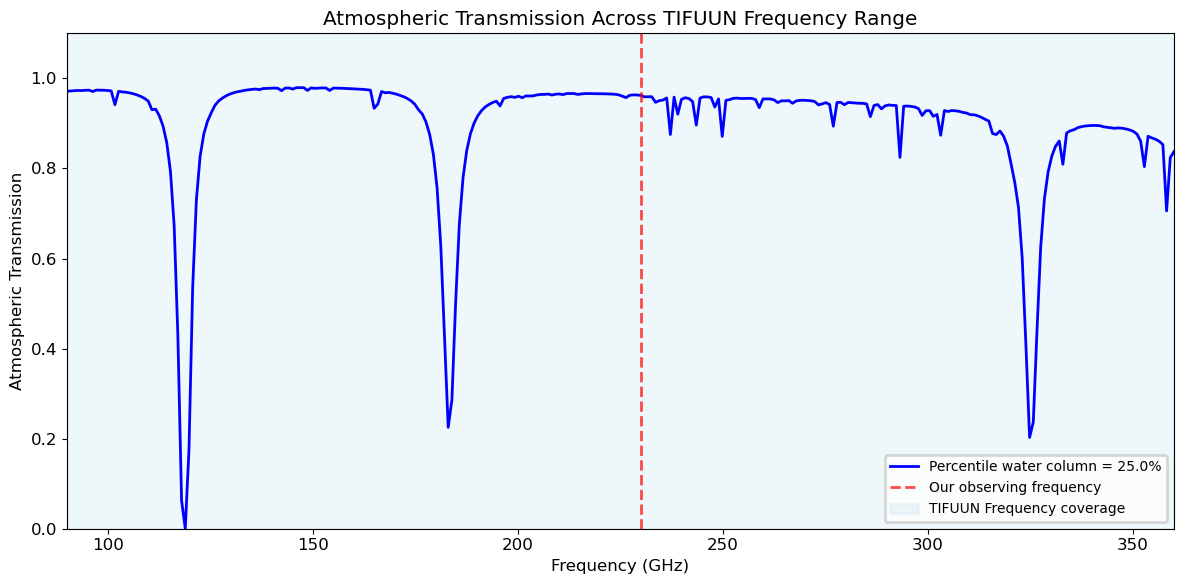

In [19]:
# Reset to our primary observing frequency
calculator.user_input.obs_freq = 230.0*u.GHz

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# plot atmospheric transmission over the TIFUUN operational frequency ranges
ax.plot(frequencies, transmission, 'b-', linewidth=2, label=f'Percentile water column = {calculator.user_input.weather}%')
# draw a vertical line at our observing frequency (dashed)
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
# draw a box to highlight the operational frequencies of the TIFUUN receiver
ax.axvspan(frequencies[0],frequencies[-1], color='lightblue', alpha=0.2, label='TIFUUN Frequency coverage')


# label the plot
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Atmospheric Transmission')
ax.set_title('Atmospheric Transmission Across TIFUUN Frequency Range')
ax.legend()
ax.set_ylim([0, 1.1])
plt.tight_layout()
plt.show()

## System Temperature Calculation

As a KID instrument, the sensitivity is calculated slightly differently to the heterodyne instruments that the sensitivity calculator was originally designed for as Poisson noise and quasiparticle recombination noise are important in addition to the wave noise, as described in detail in this [note](https://github.com/ukatc/AtLAST_sensitivity_calculator/wiki/Sensitivity-Calculation-for-a-Single%E2%80%90mode-KID-based-Instrument). By considering the resultant sensitivity equivalent to the sensitivity for a heterodyne instrument and re-arranging the equations, we find that we can incorporate this instrument into our sensitivity calculation by determining an equivalent system temperature that is dependent on the Noise Equivalent Power (NEP) as follows:

\begin{equation}
T_{sys} = \frac{\mathrm{NEP}}{k\,\eta_\mathrm{chip}\,\eta_\mathrm{co}\,\eta_\mathrm{eff}\,\mathfrak{t}\,\sqrt{2n_\mathrm{pol}\,\Delta\nu} } \nonumber
\end{equation}

where

* $\eta_\mathrm{eff}$ is the forward efficiency
* $\eta_\mathrm{chip}$ is the chip optical efficiency
* $\eta_\mathrm{co}$ is the cold optics optical efficiency
* $\mathfrak{t}$ is the atmospheric transmittance, defined as $\mathfrak{t} = \textrm{exp}^{(-\tau_{atm})}$

The Noise Equivalent Power is the square root of the sum of the Poisson noise, bunching (wave) noise and quasiparticle recombination noise and calculated as:

\begin{equation}
    \mathrm{NEP} = \sqrt{2\,P_\mathrm{KID}\,h\,\nu+2\,P_\mathrm{KID}^2/(n_\mathrm{pol}\Delta \nu)+4\,\Delta_\mathrm{g}\,P_\mathrm{KID}/\eta_{pb}} \nonumber
\end{equation}

where

* $\Delta_\mathrm{g}$ is the gap energy of the superconductor
* $\eta_\mathrm{pb}$ is the pair-breaking efficiency
* $P_\mathrm{KID}$ is the power received by the KID.

The power received by the KID ($P_\mathrm{KID}$) is dependent on the power spectral density ($PSD_\mathrm{KID}$), which is the sum of the contributions of the noise sources and calculated as:

\begin{align}
P_\mathrm{KID}(\nu_\mathrm{0}) &= \int^{\nu_\mathrm{max}}_{\nu_\mathrm{min}} PSD_\mathrm{KID}(\nu)\: d\nu \sim PSD_\mathrm{KID}(\nu_\mathrm{0}) \Delta \nu \nonumber \\

PSD_\mathrm{KID}(\nu) &=
k(\eta_\mathrm{chip}(1-\eta_\mathrm{co})\, O(\nu, T_\mathrm{co})  \nonumber\\
&+ \eta_\mathrm{chip}\,\eta_\mathrm{co}(1-\eta_\mathrm{eff})\, O(\nu, T_\mathrm{amb})  \nonumber\\
&+ \eta_\mathrm{chip}\,\eta_\mathrm{co}\,\eta_\mathrm{eff}\,T_\mathrm{sky})  \nonumber
\end{align}

where 

* $k$ is the Boltzmann constant
* $T_\mathrm{co}$ is the temperature of the cold optics
* $T_\mathrm{sky}$ is the Rayleigh-Jeans brightness temperature of the sky calculated from the model grid 
* $T_\mathrm{amb}$ is the ambient temperature.

Here, $O(\nu, T)$ is the conversion from a thermodynamic temperature to a Rayleigh-Jeans temperature

\begin{equation}
    O(\nu, T) = T \frac{h\nu/kT}{\exp(h\nu/kT)-1}.  \nonumber
\end{equation}

In the following, we will step through the calculation of the separate components of the power spectral density and the separate components of the noise equivalent power and plot to show the relative contributions of the different components.

### Power Spectral Density Calculation

The power spectral density is the power per unit frequency incident on the detector. Its calculation occurs within the instrument module. The temperature of the cold optics, the ambient temperature of the telescope and the sky temperature all contribute to the power spectral density. The separate components are not extractable by the user and so we recalculate them here in the same manner as in the calculator in order to help with the validation of the instrument implementation.

In [ ]:
# expose the TIFUUN instrument module in order to pull out the parameters used in the calculations
TIFUUN_instrument = calculator._param_setup.chosen_instrument

# read in the constants necessary for the following equations
eta_chip = TIFUUN_instrument.eta_chip
eta_co = TIFUUN_instrument.eta_co
T_co = TIFUUN_instrument.T_co
delta_g = TIFUUN_instrument.delta_g
eta_pb = TIFUUN_instrument.eta_pb
eta_eff = calculator.telescope_and_environment.eta_eff
T_amb = calculator.telescope_and_environment.T_amb

# ensure the frequencies have a unit
frange = frequencies*u.GHz

# calculate the power spectral density components for the cold optics, ambient temperature and sky temperature
# note here that the cold optics and ambient temperatures need to be converted to noise temperatures, but
# the sky temperature is already a noise temperature
# note also that the sky temperature includes the cosmic microwave background
psdkid_co = (eta_chip * (1 - eta_co) * constants.k_B * noise_temperature(T_co, frange)).to(u.W/u.Hz)
psdkid_amb = (eta_chip * eta_co * (1 - eta_eff) * constants.k_B * \
        noise_temperature(T_amb, frange)).to(u.W/u.Hz)
psdkid_sky = (eta_chip * eta_co * eta_eff * constants.k_B * t_sky_contribution*u.K).to(u.W/u.Hz)

# calculate the total power spectral density
psdkid = psdkid_co + psdkid_amb + psdkid_sky

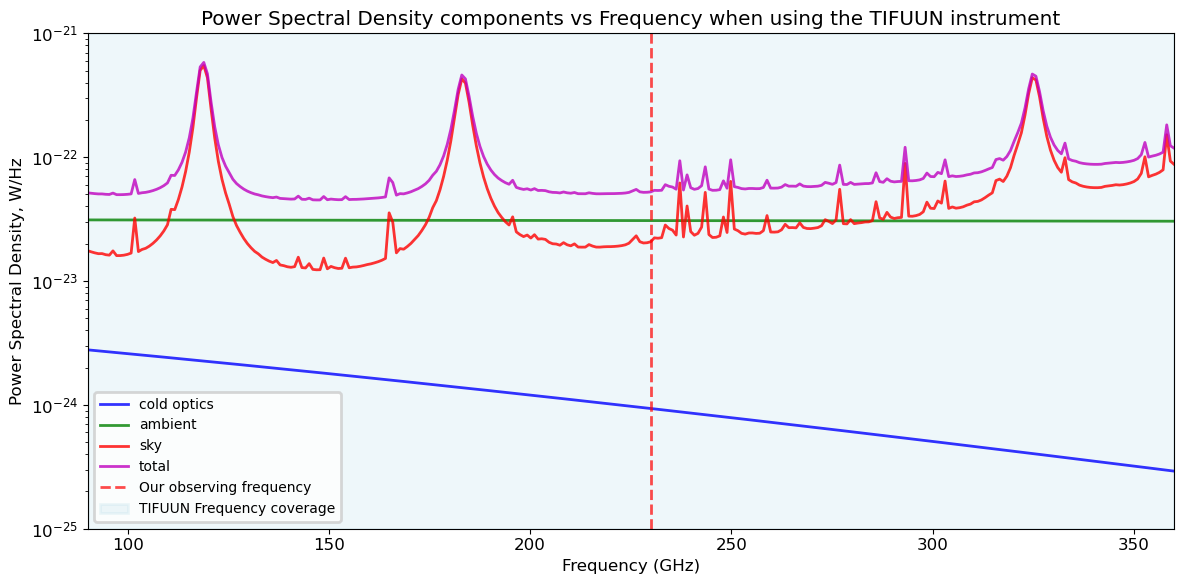

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(frequencies, psdkid_co, '-',label = 'cold optics', color='b', markersize=10, alpha=0.8)
ax.plot(frequencies, psdkid_amb, '-',label = 'ambient', color='g', markersize=10, alpha=0.8)
ax.plot(frequencies, psdkid_sky, '-',label = 'sky', color='r', markersize=10, alpha=0.8)
ax.plot(frequencies, psdkid, '-',label = 'total', color='m', markersize=10, alpha=0.8)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
#draw a box to highlight the operational frequencies of the TIFUUN receiver
ax.axvspan(frequencies[0],frequencies[-1], color='lightblue', alpha=0.2, label='TIFUUN Frequency coverage')

ax.legend()
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Power Spectral Density, W/Hz')
ax.set_title('Power Spectral Density components vs Frequency when using the TIFUUN instrument')

plt.yscale('log')
plt.ylim(1e-25, 1e-21)
plt.tight_layout()
plt.show()

### Noise Equivalent Power Calculation

The Noise Equivalent Power of a KID is made up of the Poisson noise, wave noise and quasi-particle recombination noise. As with the PSD, these components are calculated within the instrument module and are not extractable by the user and so recalculate them here to help with the instrument validation.

In [ ]:
# Set-up the range of bandwidths
brange = frange / r_power

# Convert the power spectral density to the power received by the KID
pkid = (psdkid * brange).to(u.W)

# Calculate the separate contributions to the square of the Noise Equivalent Power
nep2poisson = (2 * pkid * constants.h * frange).to(u.Hz**(-1)*u.W**2)
nep2wave = (2 * pkid**2 / (calculator.user_input.n_pol * brange)).to(u.Hz**(-1)*u.W**2)
nep2quasiparticle = (4 * delta_g * pkid / eta_pb).to(u.Hz**(-1)*u.W**2)

# Calculate the total Noise Equivalent Power
nep = np.sqrt(nep2poisson + nep2wave + nep2quasiparticle)

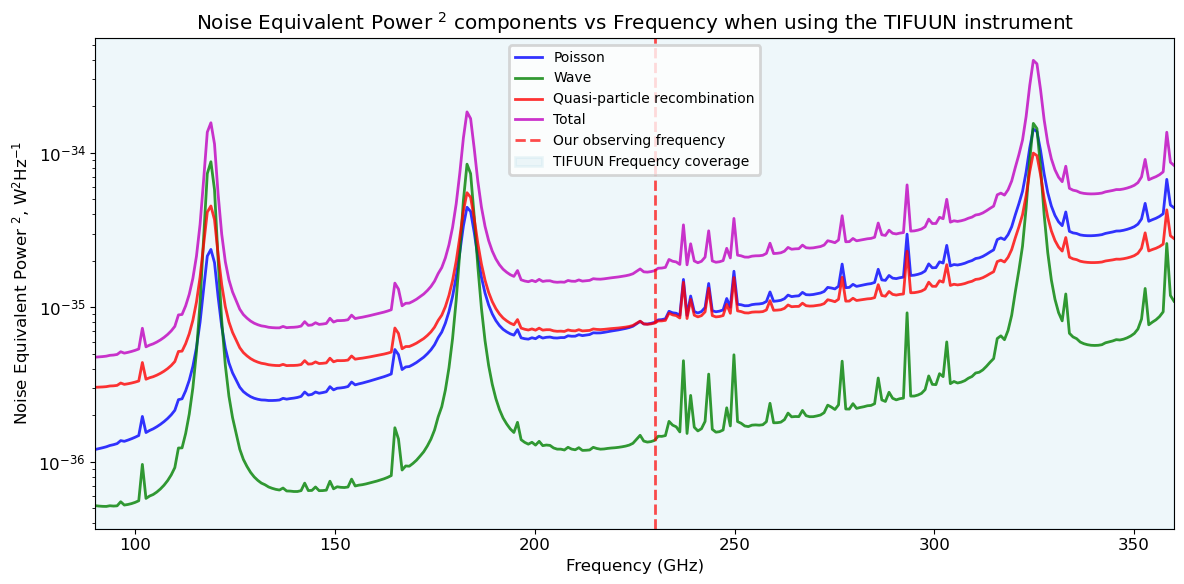

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(frequencies, nep2poisson, '-',label = 'Poisson', color='b', markersize=10, alpha=0.8)
ax.plot(frequencies, nep2wave, '-',label = 'Wave', color='g', markersize=10, alpha=0.8)
ax.plot(frequencies, nep2quasiparticle, '-',label = 'Quasi-particle recombination', color='r', markersize=10, alpha=0.8)
ax.plot(frequencies, nep**2, '-',label = 'Total', color='m', markersize=10, alpha=0.8)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
# draw a box to highlight the operational frequencies of the TIFUUN receiver
ax.axvspan(frequencies[0],frequencies[-1], color='lightblue', alpha=0.2, label='TIFUUN Frequency coverage')

ax.legend()
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Noise Equivalent Power $^2$, W$^2$Hz$^{-1}$')
ax.set_title('Noise Equivalent Power $^2$ components vs Frequency when using the TIFUUN instrument')

plt.yscale('log')
plt.tight_layout()
plt.show()

## SEFD Calculation

The System Equivalent Flux Density (SEFD) characterises the sensitivity of the telescope system. The system temperature derived in the instrument module is used to calculate the overall SEFD for the telescope, which is then used to calculate the sensitivity.

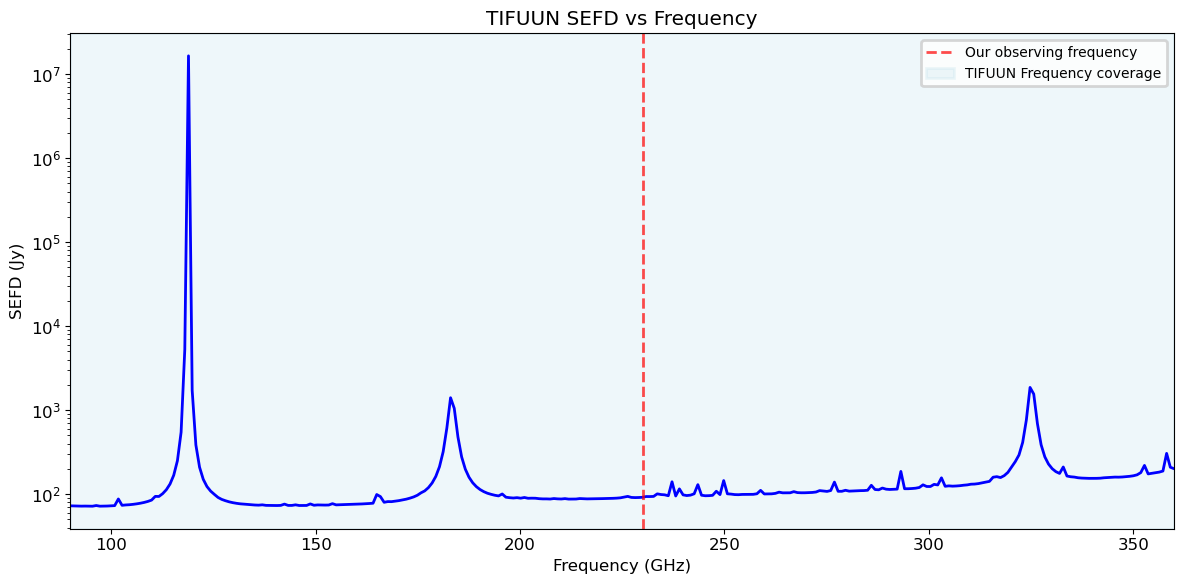

In [35]:
# Plot SEFD as a function of frequency
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(frequencies, sefd_values, 'b-', linewidth=2)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
#draw a box to highlight the operational frequencies of the TIFUUN receiver
ax.axvspan(frequencies[0],frequencies[-1], color='lightblue', alpha=0.2, label='TIFUUN Frequency coverage')

ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('SEFD (Jy)')
ax.set_yscale('log')
ax.set_title('TIFUUN SEFD vs Frequency')

ax.legend()
plt.tight_layout()
plt.show()

## Sensitivity Calculation

With all of those underlying values calculated and plotted, now let's calculate the RMS sensitivity of the telescope when using the TIFUUN instrument.

Sensitivity for an integration time of 30.0 min


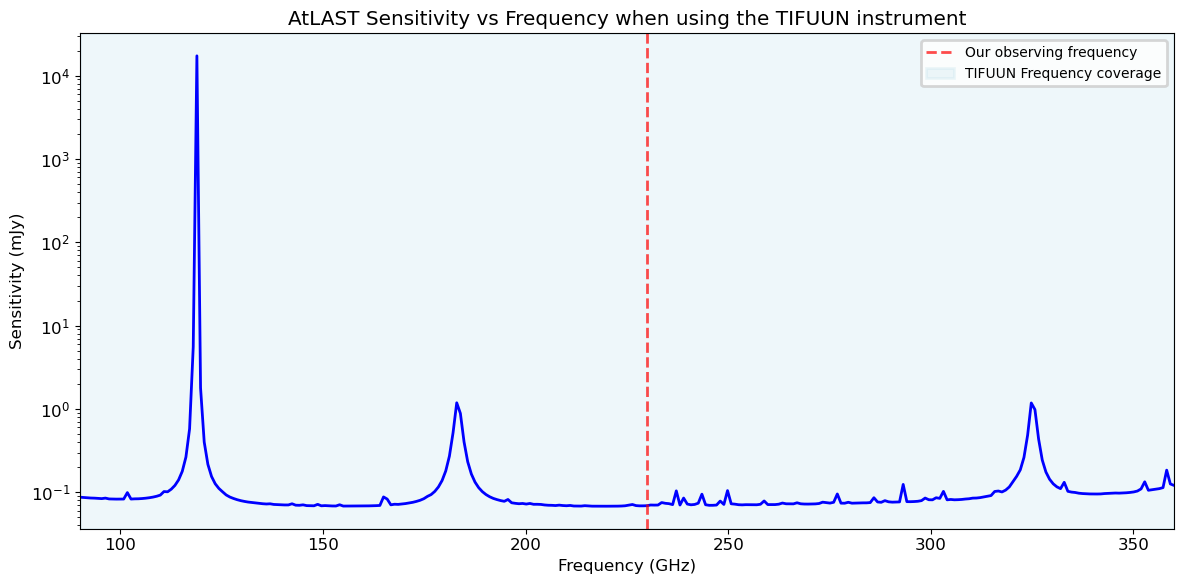

In [36]:
# Remind ourselves of the integration time used for this calculation
print(f"Sensitivity for an integration time of {calculator.user_input.t_int}")

# Show calculated sensitivity
fig, ax = plt.subplots(figsize=(12, 6))
# extract the astropy quantity sensitivities from the sensitivity array calculated above
ax.plot(frequencies, [q.to("mJy").value for q in sensitivity], 'b-', linewidth=2)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
#draw a box to highlight the operational frequencies of the TIFUUN receiver
ax.axvspan(frequencies[0],frequencies[-1], color='lightblue', alpha=0.2, label='TIFUUN Frequency coverage')

ax.set_yscale('log')
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Sensitivity (mJy)')
ax.set_title('AtLAST Sensitivity vs Frequency when using the TIFUUN instrument')

ax.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook has demonstrated the key capabilities of the AtLAST Sensitivity Calculator for the TIFUUN instrument:

1. **Instrument Selection**: Verified automatic selection and demonstrated explicit instrument setting
2. **Frequency Coverage**: Explored TIFUUN's 272-376 GHz range
3. **Atmospheric Effects**: Analysed transmission and emission across the TIFUUN operating frequency ranges
4. **System Performance**: Calculated system temperature, its components, and the overall SEFD
5. **Sensitivity Predictions**: Evaluated spectral line sensitivities across the TIFUUN frequency range